## Final Project
## Name: [Yixiao Zhang]
## Link to your the github repo: [https://github.com/adelezhangyi/DATA-1030-Project.git]

In [1]:
from __future__ import print_function
from packaging.version import parse as Version
from platform import python_version

OK = '\x1b[42m[ OK ]\x1b[0m'
FAIL = "\x1b[41m[FAIL]\x1b[0m"

try:
    import importlib
except ImportError:
    print(FAIL, "Python version 3.12 is required,"
                " but %s is installed." % sys.version)

def import_version(pkg, min_ver, fail_msg=""):
    mod = None
    try:
        mod = importlib.import_module(pkg)
        if pkg in {'PIL'}:
            ver = mod.VERSION
        else:
            ver = mod.__version__
        if Version(ver) == Version(min_ver):
            print(OK, "%s version %s is installed."
                  % (lib, min_ver))
        else:
            print(FAIL, "%s version %s is required, but %s installed."
                  % (lib, min_ver, ver))    
    except ImportError:
        print(FAIL, '%s not installed. %s' % (pkg, fail_msg))
    return mod


# first check the python version
pyversion = Version(python_version())

if pyversion >= Version("3.12.5"):
    print(OK, "Python version is %s" % pyversion)
elif pyversion < Version("3.12.5"):
    print(FAIL, "Python version 3.12.5 is required,"
                " but %s is installed." % pyversion)
else:
    print(FAIL, "Unknown Python version: %s" % pyversion)

    
print()
requirements = {'numpy': "1.26.4", 'matplotlib': "3.9.2",'sklearn': "1.5.1", 
                'pandas': "2.2.2",'xgboost': "2.1.1", 'shap': "0.45.1", 
                'plotly': "5.23.0"}

# now the dependencies
for lib, required_version in list(requirements.items()):
    import_version(lib, required_version)

[ OK ] Python version is 3.12.5

[ OK ] numpy version 1.26.4 is installed.
[ OK ] matplotlib version 3.9.2 is installed.
[ OK ] sklearn version 1.5.1 is installed.
[ OK ] pandas version 2.2.2 is installed.
[ OK ] xgboost version 2.1.1 is installed.
[ OK ] shap version 0.45.1 is installed.
[ OK ] plotly version 5.23.0 is installed.


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('marketing_campaign_data.csv')
print("Number of datapoints:", len(df))
print(df.head())


Number of datapoints: 2240
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524      1957.0  Graduation         Single  58138.0        0         0   
1  2174         NaN  Graduation         Single  46344.0        1         1   
2  4141         NaN  Graduation       Together      NaN        0         0   
3  6182         NaN  Graduation       Together  26646.0        1         0   
4  5324         NaN         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       NaN  ...                  7             0   
1  08-03-2014       38       NaN  ...                  5             0   
2  21-08-2013       26     426.0  ...                  4             0   
3  10-02-2014       26      11.0  ...                  6             0   
4  19-01-2014       94     173.0  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  

## Exploratory Data Analysis (EDA)

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,1162.0,1968.864028,11.531349,1940.0,1960.00,1970.0,1977.00,1995.0
Income,1150.0,51604.226087,21625.580361,2447.0,35182.50,50840.0,67429.75,160803.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,1162.0,305.436317,341.467278,0.0,23.00,175.5,502.75,1493.0
MntFruits,1162.0,26.387263,38.992609,0.0,2.00,9.0,33.00,199.0
MntMeatProducts,1162.0,169.975904,223.593075,1.0,16.00,67.5,240.75,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


* Checking Missing Values

In [4]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display the missing values and their percentages for each column
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print("Missing values by column:")
print(missing_data.to_string())

# Calculate overall percentage of missing values in the entire dataset
total_missing = df.isnull().sum().sum()  # Sum of all missing values
total_values = df.size  # Total number of values in the dataset
overall_missing_percentage = (total_missing / total_values) * 100

print(f"\nOverall missing values percentage in the entire dataset: {overall_missing_percentage:.2f}%")


Missing values by column:
                     Missing Values  Percentage
ID                                0    0.000000
Year_Birth                     1078   48.125000
Education                         0    0.000000
Marital_Status                    0    0.000000
Income                         1090   48.660714
Kidhome                           0    0.000000
Teenhome                          0    0.000000
Dt_Customer                       0    0.000000
Recency                           0    0.000000
MntWines                       1078   48.125000
MntFruits                      1078   48.125000
MntMeatProducts                1078   48.125000
MntFishProducts                   0    0.000000
MntSweetProducts                  0    0.000000
MntGoldProds                      0    0.000000
NumDealsPurchases                 0    0.000000
NumWebPurchases                1078   48.125000
NumCatalogPurchases               0    0.000000
NumStorePurchases                 0    0.000000
NumWebVisitsMo

/var/folders/z1/qgjtgd396xq6w1n2txl607c00000gn/T/ipykernel_5473/4252974515.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data['Percentage'], palette='coolwarm')


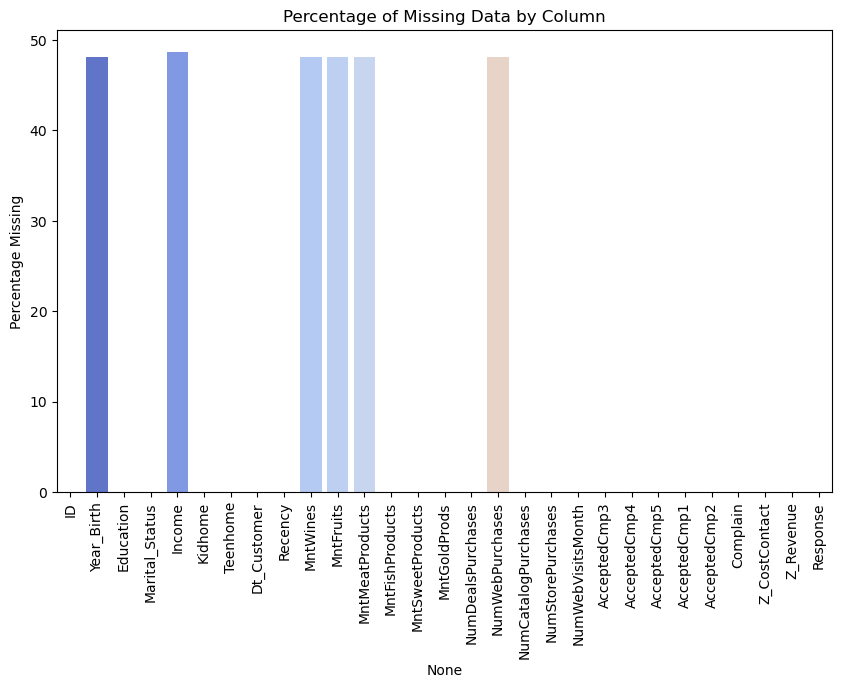

In [5]:
# Plotting the missing data percentage per column
import seaborn as sns
import matplotlib.pyplot as plt

# Create a bar plot for missing data
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.index, y=missing_data['Percentage'], palette='coolwarm')
plt.title('Percentage of Missing Data by Column')
plt.xticks(rotation=90)
plt.ylabel('Percentage Missing')
plt.show()


* Summary Statistics for Numerical Columns

In [6]:
# Summary statistics for numerical columns
summary_stats = df.describe()
print(summary_stats)


                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   2240.000000  1162.000000    1150.000000  2240.000000  2240.000000   
mean    5592.159821  1968.864028   51604.226087     0.444196     0.506250   
std     3246.662198    11.531349   21625.580361     0.538398     0.544538   
min        0.000000  1940.000000    2447.000000     0.000000     0.000000   
25%     2828.250000  1960.000000   35182.500000     0.000000     0.000000   
50%     5458.500000  1970.000000   50840.000000     0.000000     0.000000   
75%     8427.750000  1977.000000   67429.750000     1.000000     1.000000   
max    11191.000000  1995.000000  160803.000000     2.000000     2.000000   

           Recency     MntWines    MntFruits  MntMeatProducts  \
count  2240.000000  1162.000000  1162.000000      1162.000000   
mean     49.109375   305.436317    26.387263       169.975904   
std      28.962453   341.467278    38.992609       223.593075   
min       0.000000     0.000000     0.000000  

* Distribution of Key Features

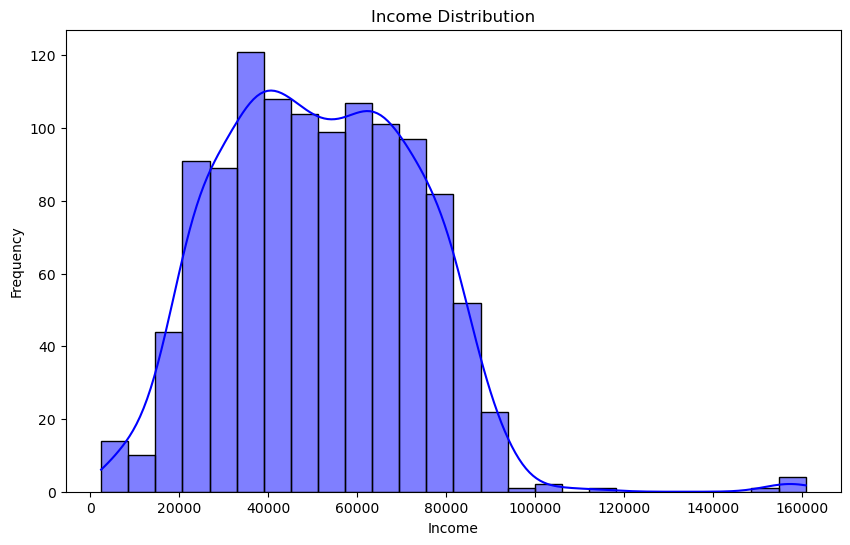

In [7]:
# Plot Income distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'].dropna(), kde=True, color='blue')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()


 The distribution of income is right-skewed, with most customers earning between X and Y. This insight could be used to segment customers for targeted campaigns.

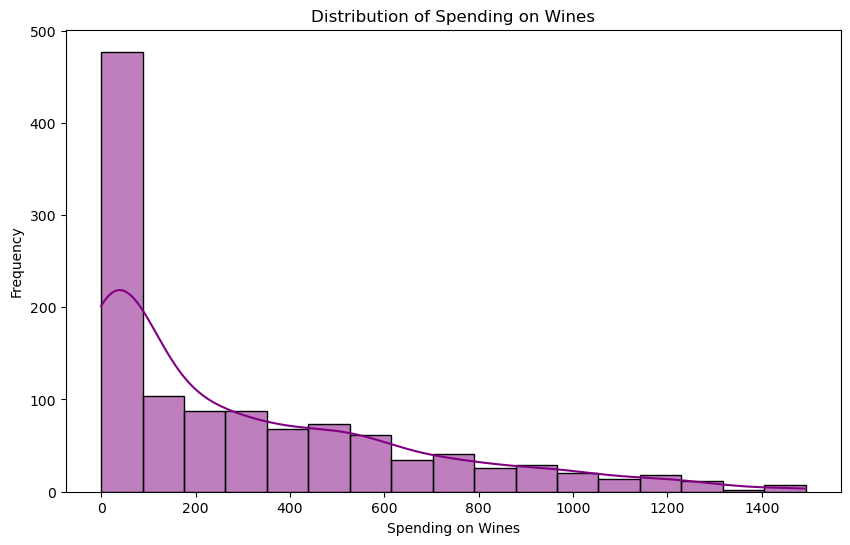

In [8]:
# Plot distribution of spending on wines
plt.figure(figsize=(10, 6))
sns.histplot(df['MntWines'], kde=True, color='purple')
plt.title('Distribution of Spending on Wines')
plt.xlabel('Spending on Wines')
plt.ylabel('Frequency')
plt.show()


* Boxplots for Outlier Detection

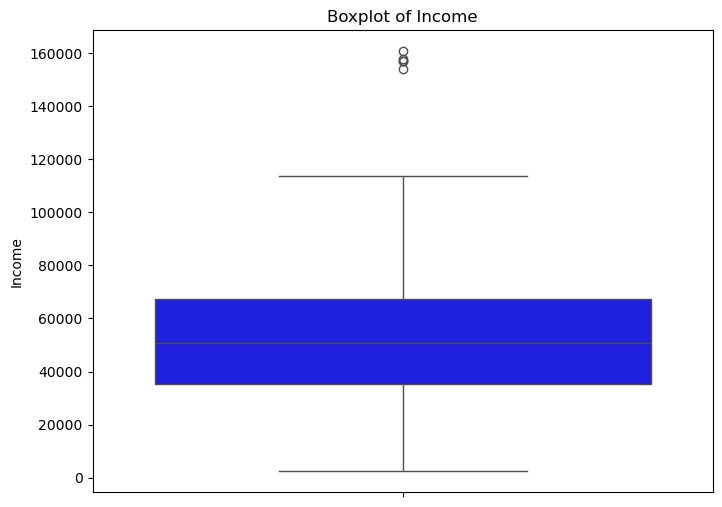

In [9]:
# Boxplot for Income
plt.figure(figsize=(8, 6))
sns.boxplot(y='Income', data=df, color='blue')
plt.title('Boxplot of Income')
plt.show()


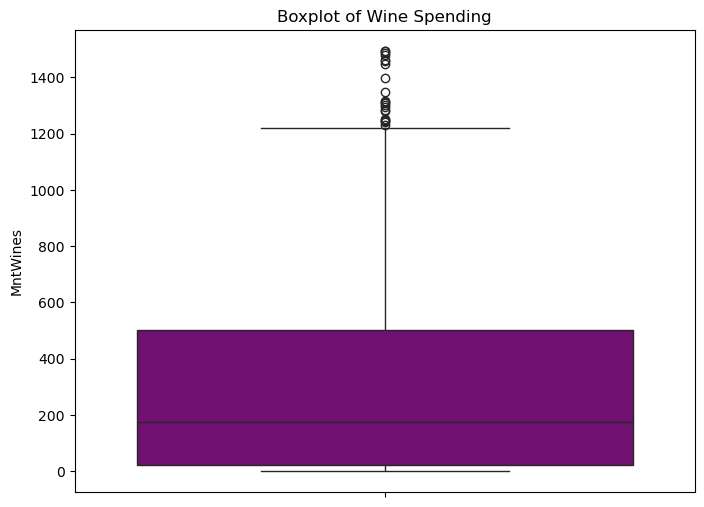

In [10]:
# Boxplot for Wine Spending
plt.figure(figsize=(8, 6))
sns.boxplot(y='MntWines', data=df, color='purple')
plt.title('Boxplot of Wine Spending')
plt.show()

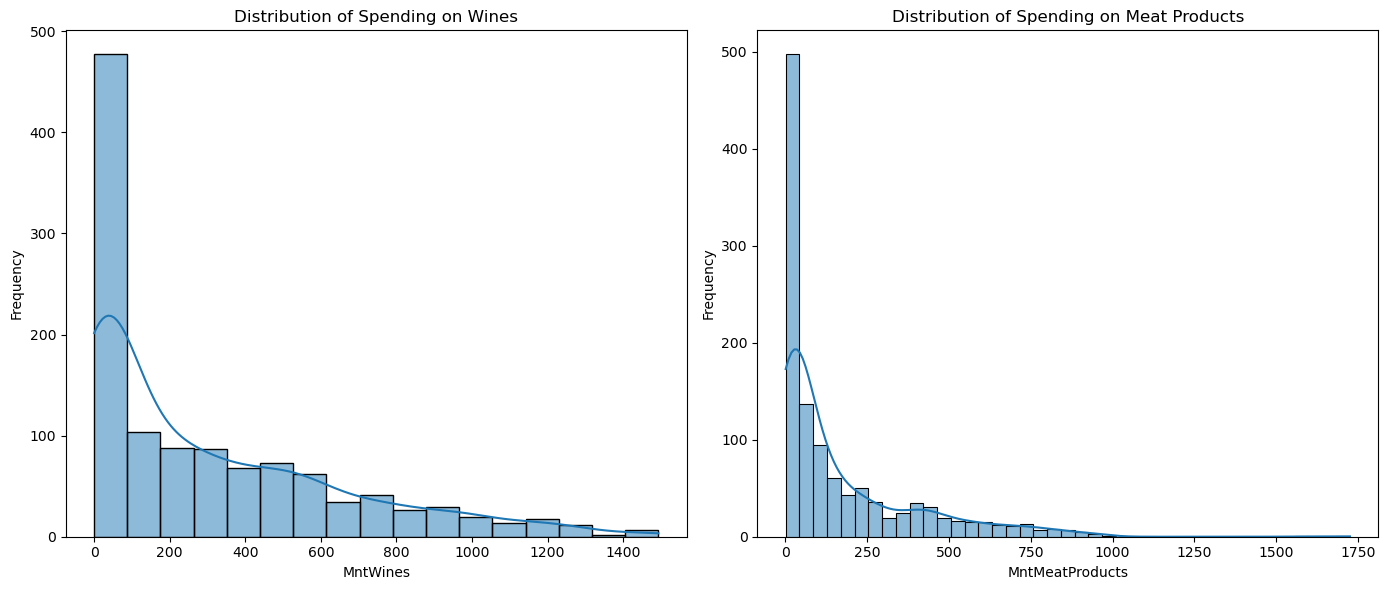

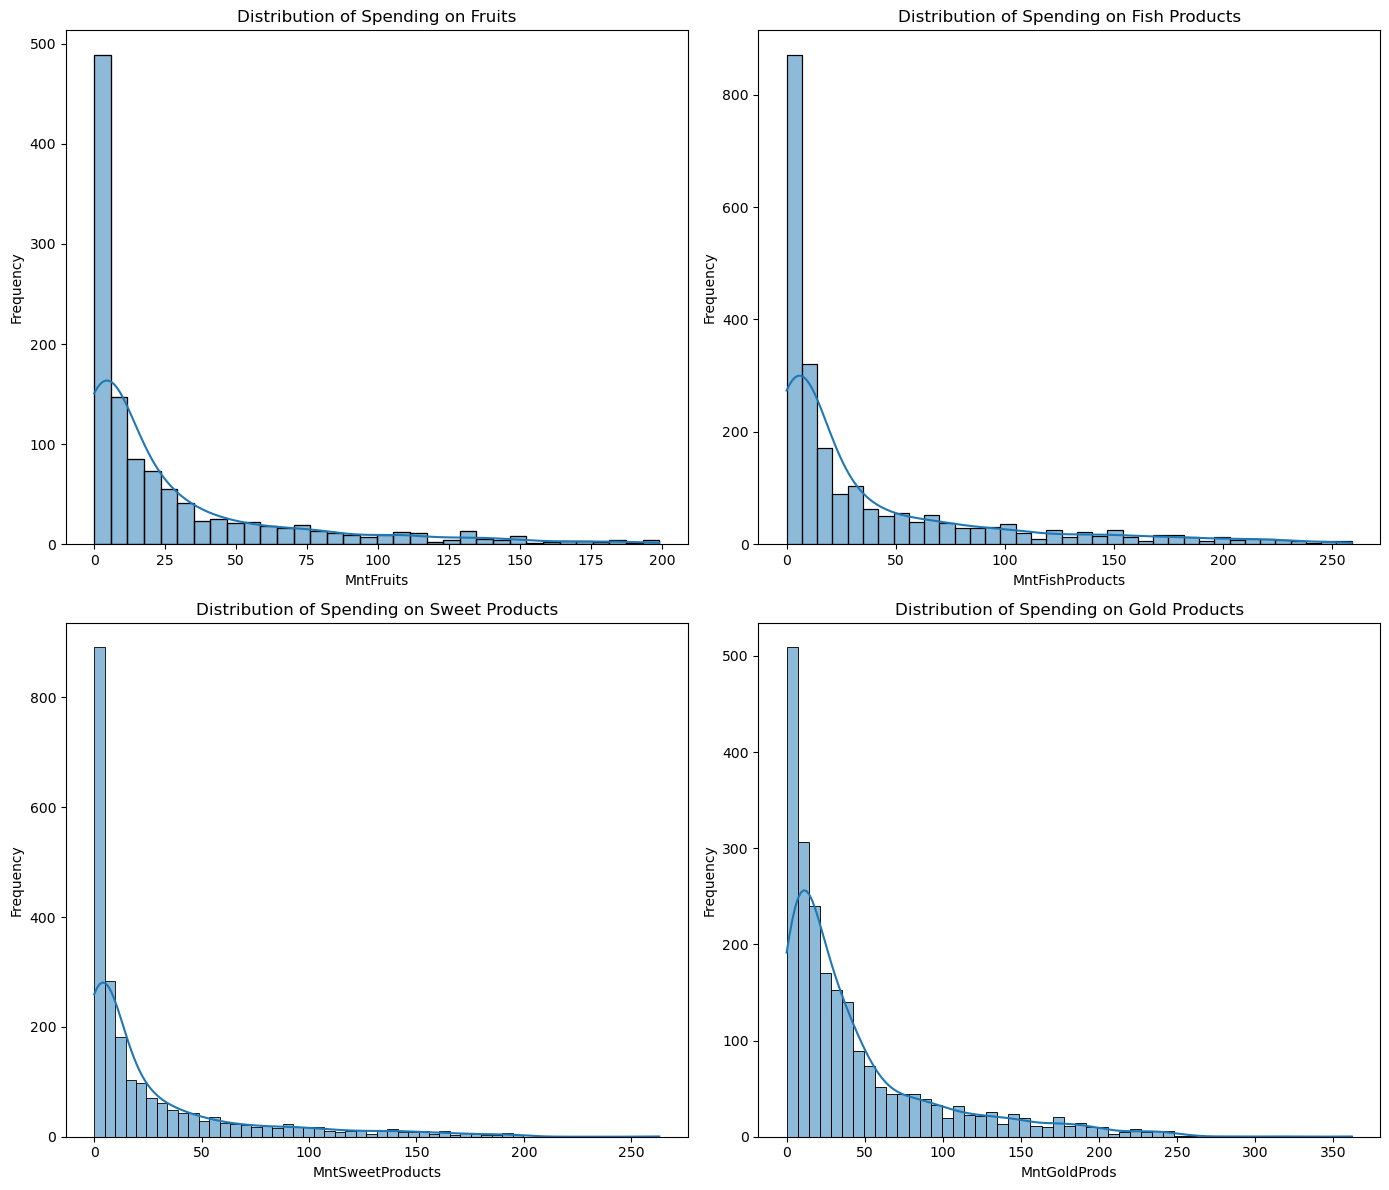

In [11]:
# Spending Group
import matplotlib.pyplot as plt
import seaborn as sns

# Group 1: Higher spending categories (Wines and Meat Products)
group1 = ['MntWines', 'MntMeatProducts']
titles_group1 = ['Wines', 'Meat Products']

# Group 2: Lower spending categories (Fruits, Fish, Sweet, and Gold Products)
group2 = ['MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
titles_group2 = ['Fruits', 'Fish Products', 'Sweet Products', 'Gold Products']

# Plot Group 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(group1):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of Spending on {titles_group1[i]}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot Group 2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(group2):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of Spending on {titles_group2[i]}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()




Relationship Between Features

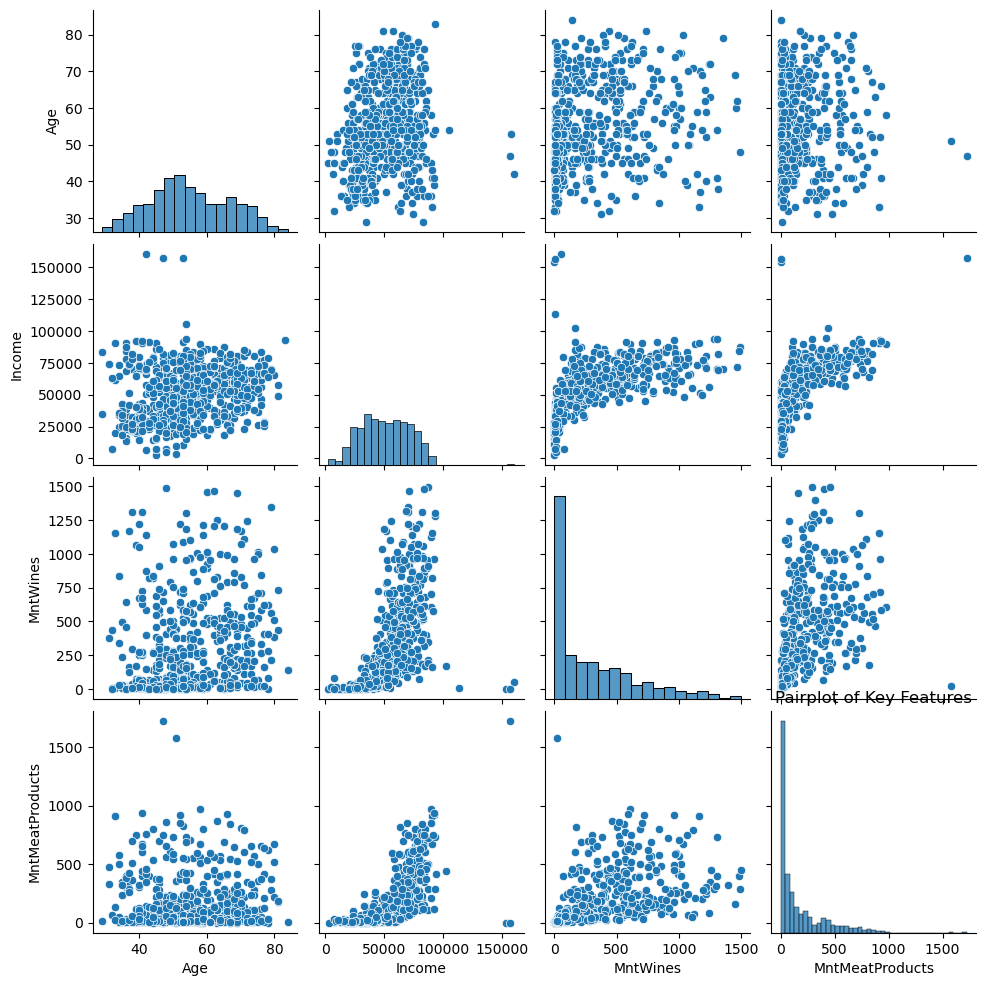

In [14]:
# Pairplot to explore relationships between multiple features
sns.pairplot(df[['Age', 'Income', 'MntWines', 'MntMeatProducts']])
plt.title('Pairplot of Key Features')
plt.show()


* Correlation Analysis

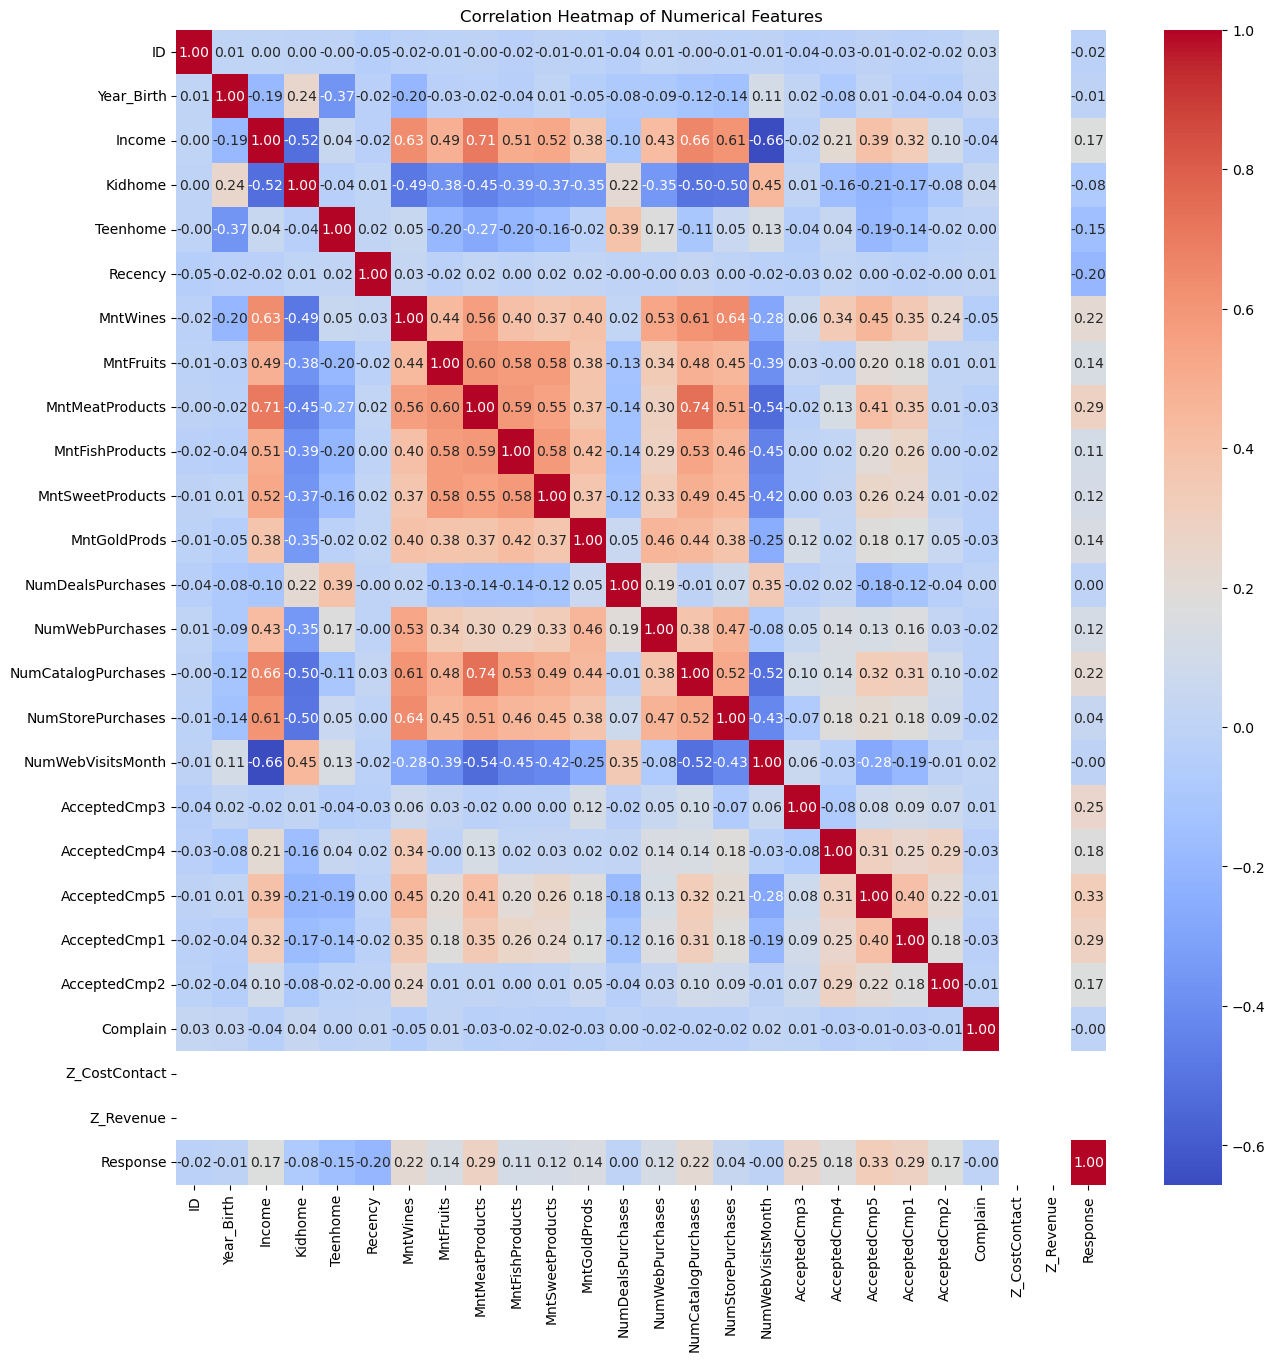

In [13]:
# Correlation heatmap

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])

# Plot the correlation heatmap for numerical columns only
plt.figure(figsize=(15, 15))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


* Bar Plots to Compare Categorical Variables

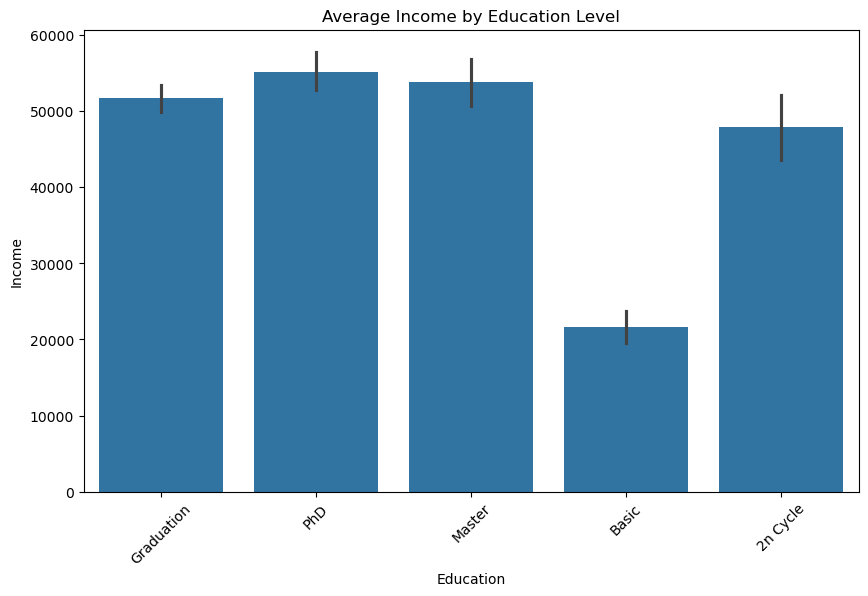

In [14]:
# Bar plot for average income per education level
plt.figure(figsize=(10, 6))
sns.barplot(x='Education', y='Income', data=df)
plt.title('Average Income by Education Level')
plt.ylabel('Income')
plt.xlabel('Education')
plt.xticks(rotation=45)
plt.show()


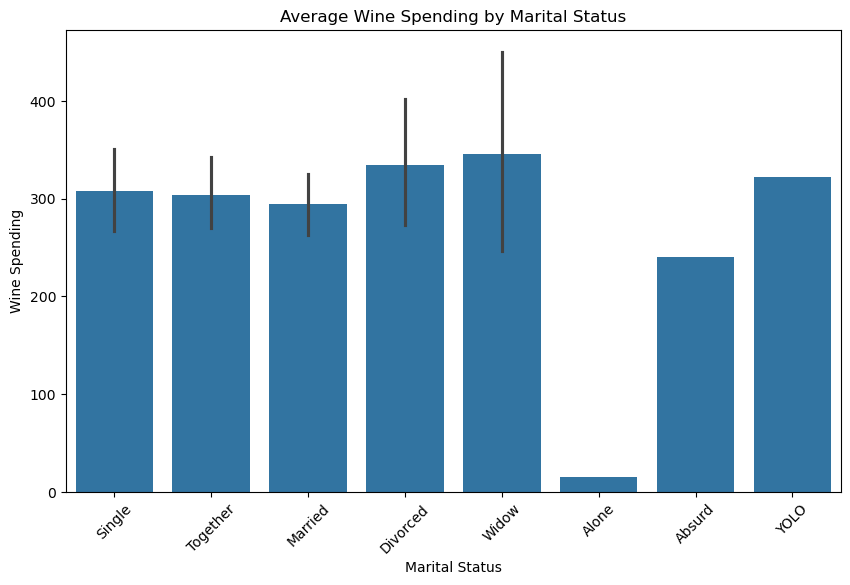

In [15]:
# Bar plot for average wine spending by marital status
plt.figure(figsize=(10, 6))
sns.barplot(x='Marital_Status', y='MntWines', data=df)
plt.title('Average Wine Spending by Marital Status')
plt.ylabel('Wine Spending')
plt.xlabel('Marital Status')
plt.xticks(rotation=45)
plt.show()

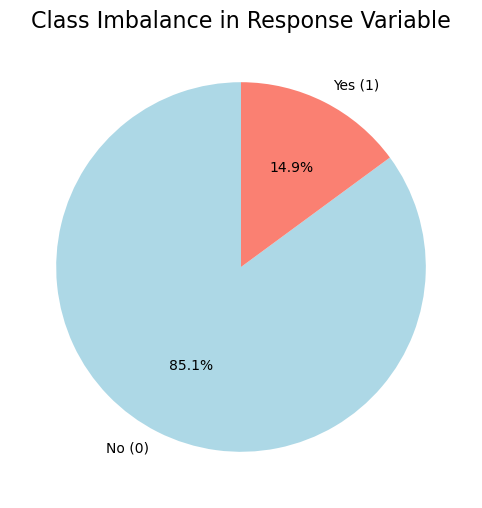

In [16]:
import matplotlib.pyplot as plt

# Count the response variable
response_counts = df['Response'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(response_counts, labels=['No (0)', 'Yes (1)'], autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
plt.title('Class Imbalance in Response Variable', fontsize = 16)
plt.show()


## Splitting and Preprocessing Slides 

### Handling Missing Values

In [17]:
# Checking the percentage of missing values in each column
print("\nPercentage of Missing Values:")
print((df.isnull().sum() / len(df)) * 100)


Percentage of Missing Values:
ID                      0.000000
Year_Birth             48.125000
Education               0.000000
Marital_Status          0.000000
Income                 48.660714
Kidhome                 0.000000
Teenhome                0.000000
Dt_Customer             0.000000
Recency                 0.000000
MntWines               48.125000
MntFruits              48.125000
MntMeatProducts        48.125000
MntFishProducts         0.000000
MntSweetProducts        0.000000
MntGoldProds            0.000000
NumDealsPurchases       0.000000
NumWebPurchases        48.125000
NumCatalogPurchases     0.000000
NumStorePurchases       0.000000
NumWebVisitsMonth       0.000000
AcceptedCmp3            0.000000
AcceptedCmp4            0.000000
AcceptedCmp5            0.000000
AcceptedCmp1            0.000000
AcceptedCmp2            0.000000
Complain                0.000000
Z_CostContact           0.000000
Z_Revenue               0.000000
Response                0.000000
dtype: float

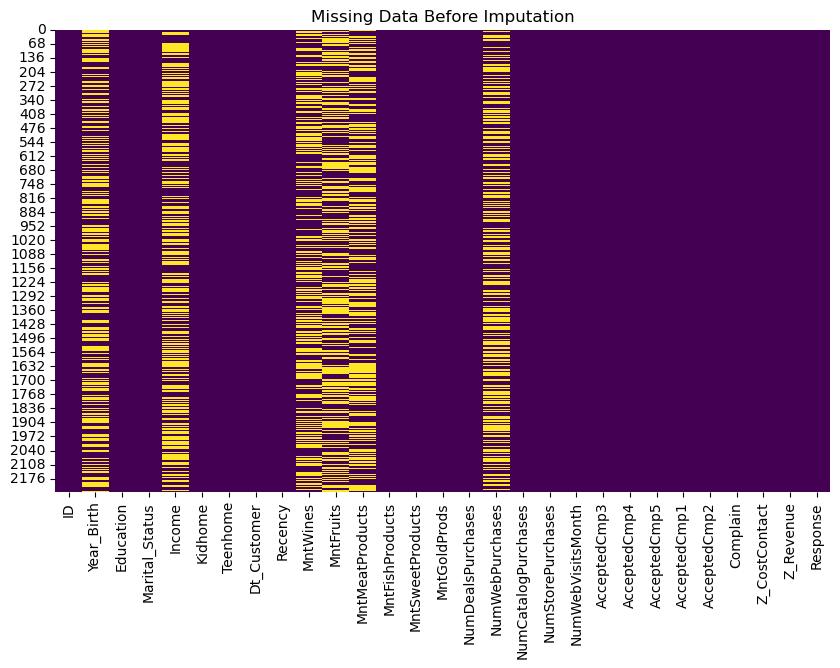

In [18]:
# Plot missing data before imputation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Before Imputation')
plt.show()


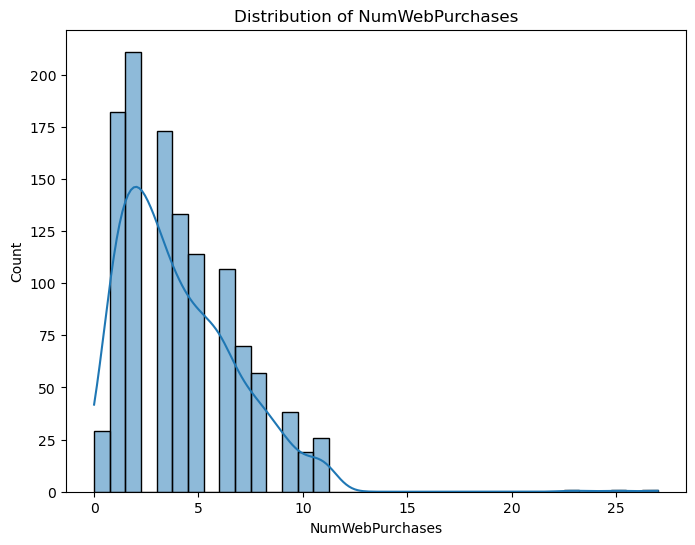

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distribution of NumWebPurchases
plt.figure(figsize=(8, 6))
sns.histplot(df['NumWebPurchases'], kde=True)
plt.title('Distribution of NumWebPurchases')
plt.show()

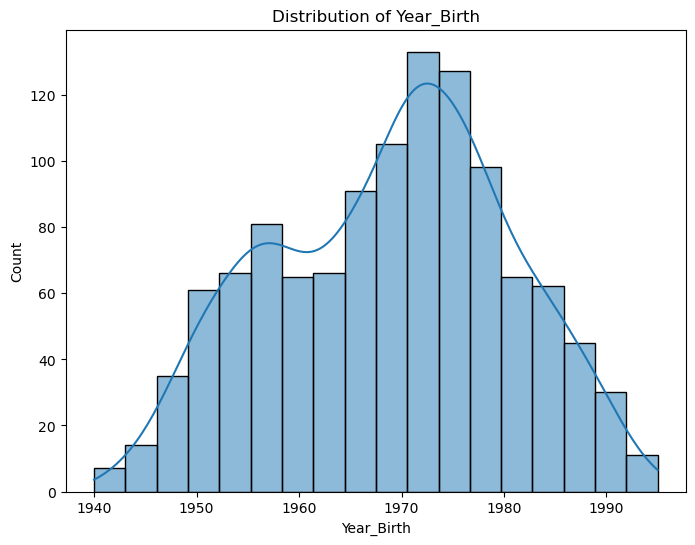

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distribution of NumWebPurchases
plt.figure(figsize=(8, 6))
sns.histplot(df['Year_Birth'], kde=True)
plt.title('Distribution of Year_Birth')
plt.show()

In [8]:
spending_columns = ['Income','Year_Birth','MntWines', 'MntFruits', 'MntMeatProducts', 'NumWebPurchases']
for col in spending_columns:
    df[col].fillna(df[col].median(), inplace=True)


/var/folders/z1/qgjtgd396xq6w1n2txl607c00000gn/T/ipykernel_5405/612877939.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/z1/qgjtgd396xq6w1n2txl607c00000gn/T/ipykernel_5405/612877939.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [9]:
print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


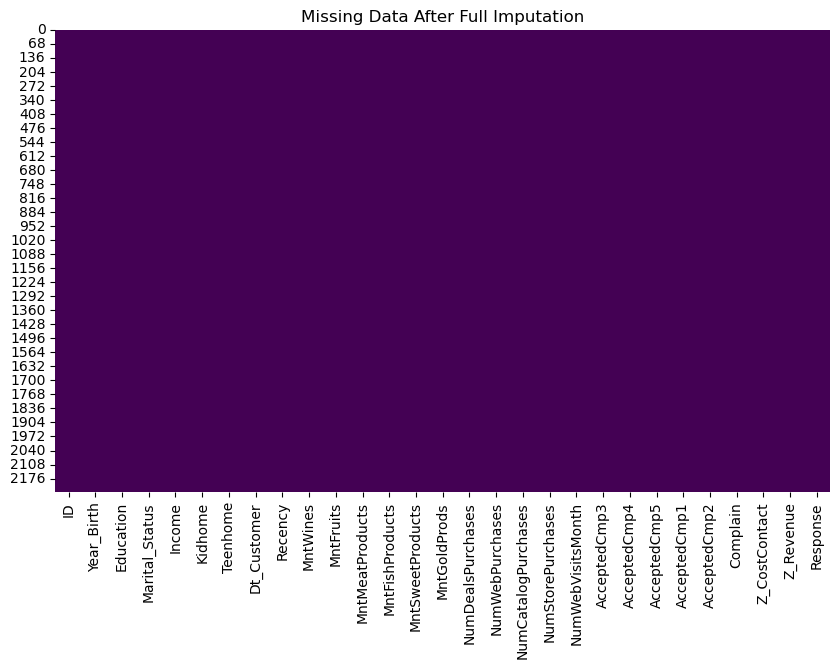

In [10]:
# Plot missing data after full imputation
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data After Full Imputation')
plt.show()



### Split the Dataset

In [11]:
from sklearn.model_selection import train_test_split

# Defining features (X) and target (y)
X = df.drop('Response', axis=1)
y = df['Response']

# Split the dataset into 80% training, 10% validation, and 10% testing
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Output size of the splits
print(f"Training Data Points: {X_train.shape[0]}")
print(f"Validation Data Points: {X_val.shape[0]}")
print(f"Testing Data Points: {X_test.shape[0]}")

Training Data Points: 1792
Validation Data Points: 224
Testing Data Points: 224


### Preprocessing (Scaling and Encoding)

In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Specify numerical and categorical columns
numerical_columns = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 
                     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 
                     'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 
                     'NumStorePurchases', 'NumWebVisitsMonth']

categorical_columns = ['Education', 'Marital_Status', 'Complain', 
                       'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
                       'AcceptedCmp4', 'AcceptedCmp5']

# Define a transformer for scaling and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)
    ])


# Fit and transform on the training data
X_train = preprocessor.fit_transform(X_train)

# Only transform the validation and test data (using parameters learned from the training data)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

# Output the transformed dataset (first 5 rows of training data)
print(X_train[:5])  # Show first 5 rows of the transformed training data
print(X_val[:5])  # Show first 5 rows of the transformed validation data
print(X_test[:5])  # Show first 5 rows of the transformed test data


[[-0.01860352  0.44494334 -0.27088617 -0.30093582  4.46700658 -0.22992492
   1.64592496 -0.10900207 -0.68640646 -0.2665944   1.19574462  0.38341581
  -1.36158848  0.          0.          0.          1.          0.
   0.          1.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          1.        ]
 [-0.01860352 -0.89517906  2.9424852   0.14165262 -0.31032276  0.38736887
   0.99393153  0.02499655 -0.68640646 -0.2665944   1.19574462  1.92395645
  -0.95506289  0.          0.          0.          1.          0.
   0.          0.          1.          0.          0.          0.
   0.          1.          0.          0.          0.          1.        ]
 [-0.01860352 -0.48283371 -0.27088617 -0.16475476 -0.37500614 -0.24808062
  -0.28590742 -0.35785666  0.86602144 -0.2665944  -0.56756542 -0.54090858
   0.67103944  0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   0.     

### Summary of Features and Data Points

In [13]:
# Checking the number of features and data points before and after preprocessing
initial_features = df.shape[1]
initial_data_points = df.shape[0]

processed_features = X_train.shape[1]
training_data_points = X_train.shape[0]
validation_data_points = X_val.shape[0]
testing_data_points = X_test.shape[0]

# Summary of the preprocessing and splitting
preprocessing_summary = {
    "Initial Features": initial_features,
    "Initial Data Points": initial_data_points,
    "Processed Features": processed_features,
    "Training Data Points": training_data_points,
    "Validation Data Points": validation_data_points,
    "Testing Data Points": testing_data_points
}

# Display the preprocessing summary
print(pd.DataFrame.from_dict(preprocessing_summary, orient='index', columns=['Value']))


                        Value
Initial Features           29
Initial Data Points      2240
Processed Features         30
Training Data Points     1792
Validation Data Points    224
Testing Data Points       224
